In [8]:
import shutil
import pandas as pd
import random

import copy
import numpy as np # Import numpy for checking finite values
import matplotlib.pyplot as plt # Import matplotlib for potential debugging

import os
import math # Import math for ceil
from sklearn.manifold import TSNE # Import TSNE to check default perplexity

import os
import glob
import json
import numpy as np
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [9]:
import sys
fixed_path = 'C:\\Users\\admin\\0.Master_Thesis\\'
if fixed_path not in sys.path:
    sys.path.append(fixed_path)

cellcnn_path = f'{fixed_path}CellCNN/'
if cellcnn_path not in sys.path:
    sys.path.append(cellcnn_path)


old_cellcnn_path = f'{fixed_path}CellCNN/Old_CellCNN/'
if old_cellcnn_path not in sys.path:
    sys.path.append(old_cellcnn_path)

general_functions_path = f'{fixed_path}General_Functions/'
if general_functions_path not in sys.path:
    sys.path.append(general_functions_path)

save_path = f'{fixed_path}CellCNN/results/'
if save_path not in sys.path:
    sys.path.append(save_path)

In [10]:
decache_files = ['timepoints_elaboration', 'results_elaboration', 'new_datasets_generation', 'run_models',
                 'old_cellCnn.model', 'old_cellCnn.utils', 'old_cellCnn.downsample', 'old_cellCnn.model_grid' ]

# Rimuovi il modulo specifico dalla cache
from timepoints_elaboration import remove_from_cache
remove_from_cache(decache_files)


# import downloaded modules
from old_cellCnn.model import CellCnn

import old_cellCnn.utils as utils
import old_cellCnn.downsample as downsample

from timepoints_elaboration import load_data, donation_extraction, dataset_elaboration
from timepoints_elaboration import donor_division, patient_code_extraction, remove_from_cache

from results_elaboration import extract_hyper, phenotype_prediction, default_serializer, show_hyperparameters
from results_elaboration import elaborate_predictions, show_hyper

from run_models import trials_train_CellCNN, trials_test_CellCNN, trials_train_CellCNN_old, trials_test_CellCNN_old

from new_datasets_generation import splitting_and_dataset_elaboration

timepoints_elaboration rimosso dalla cache
results_elaboration non trovato nella cache
new_datasets_generation non trovato nella cache
run_models non trovato nella cache
old_cellCnn.model non trovato nella cache
old_cellCnn.utils non trovato nella cache
old_cellCnn.downsample non trovato nella cache
old_cellCnn.model_grid non trovato nella cache


In [11]:
%%time

# Trova tutti i file con estensione specifica in una cartella
data_folder = f'{fixed_path}B-ALL_Datasets'
extension = '*.csv'  # cambia con l'estensione che ti serve

multiple_donations, ALL_DATASETS = load_data(data_path = data_folder, ext = extension)

Elaborating file 0: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_220204-2900.csv
Elaborating file 1: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_220208-3665.csv
Elaborating file 2: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_220216-3546.csv
Elaborating file 3: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D15_1.csv
Elaborating file 4: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D29_1.csv
Elaborating file 5: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D71_1.csv
Elaborating file 6: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE12_D15_2.csv
Elaborating file 7: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE12_D29_1.csv
Elaborating file 8: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE1_D15_2.csv
Elaborating

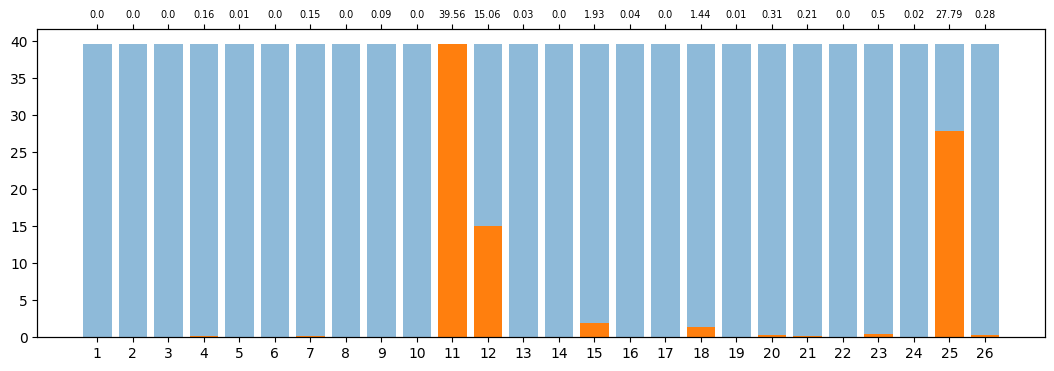

[6558750, 2764877, 1291729, 843500, 1404000, 3265250, 430869, 722000, 864000, 1947518, 778750, 5510750, 208000, 2912500, 160500, 3591480, 3107000, 637409, 2928000, 164553, 191975, 169000, 479000, 455000, 160828, 505000]
[0, 0, 0, 1348, 170, 0, 639, 15, 757, 0, 308059, 830101, 72, 0, 3096, 1449, 0, 9147, 227, 518, 398, 0, 2390, 77, 44697, 1413]


In [12]:
def show_blast_distribution(ALL_DATASETS, return_perc = False):
    tot_perc_list = []
    tot_blast_num_list = []
    for i, dataset in enumerate(ALL_DATASETS):
        blast_n = (dataset['IsBlast'] == 1).sum()
        tot_perc_list.append(round((blast_n/len(dataset))*100, 2))
        tot_blast_num_list.append(blast_n)
    positions = range(1, len(tot_perc_list) + 1)
    
    fig, ax1 = plt.subplots(figsize = [len(positions)/2,4])
    ax1.bar(list(range(1, len(tot_perc_list) + 1)), [max(tot_perc_list)]*len(tot_perc_list), alpha = 0.5)
    ax1.bar(list(range(1, len(tot_perc_list) + 1)), tot_perc_list)
    ax1.set_xticks(positions)
    
    ax2 = ax1.twiny()
    ax2.set_xlim(ax1.get_xlim())
    ax2.set_xticks(ax1.get_xticks()) # Positions [1, 2, 3, 4]
    
    ax2.set_xticklabels(tot_perc_list, size = 'x-small')
    plt.show()

    if return_perc:
        print([len(ds) for ds in ALL_DATASETS])
        return tot_perc_list, tot_blast_num_list
tot_perc_list, tot_blast_num_list = show_blast_distribution(ALL_DATASETS, return_perc = True)
print( tot_blast_num_list)

In [13]:
print(multiple_donations)

{'11': [3, 4, 5], '12': [6, 7], '1': [8, 9], '2': [10, 11], '3': [12, 13], '4': [14, 15, 16], '6': [17, 18], '7': [19, 20, 21], '8': [22, 23], '9': [24, 25], '13': [0], '14': [1], '15': [2]}


In [14]:
healthy_donors, blast_donors, mixed_donors = donor_division(multiple_donations, ALL_DATASETS)

print(healthy_donors, blast_donors, mixed_donors)

# Samples donors for Train, Validation and Test sets    
seed = 105619

train_donors_idx, val_donors_idx, test_donors_idx = dataset_elaboration(multiple_donations, ALL_DATASETS, healthy_donors, blast_donors,
                        mixed_donors, seed = seed)



{'11': [1, 1, 0], '12': [1, 1], '1': [1, 0], '2': [1, 1], '3': [1, 0], '4': [1, 1, 0], '6': [1, 1], '7': [1, 1, 0], '8': [1, 1], '9': [1, 1], '13': [0], '14': [0], '15': [0]}
['13', '14', '15'] ['12', '2', '6', '8', '9'] ['11', '1', '3', '4', '7']
Precess starts. Dividing donors...
healthy_donors_idx, blast_donors_idx, mixed_donors_idx: [0, 2, 1], [0, 4, 2, 1, 3],[4, 0, 2, 1, 3]
Seting Train, Validation and Test idx...
['12', '9', '13', '7'] ['6', '15', '3'] ['2', '8', '14', '11', '1', '4']


In [15]:
# classical CV 3 fold
def classic_CV_train_val_splits(healthy_donors, blast_donors, mixed_donors,  test_donors_idx, folds = 3):
    h_pat, b_pat, m_pat = healthy_donors.copy(), blast_donors.copy(), mixed_donors.copy()

    tot_pat = []
    for pat in test_donors_idx:
        if pat in healthy_donors:
            h_pat.remove(pat)
        if pat in blast_donors:
             b_pat.remove(pat)
        if pat in mixed_donors:
            m_pat.remove(pat)

    from itertools import zip_longest
    
    tot_pat = []
    for pat_1, pat_2, pat_3 in zip_longest(h_pat, b_pat, m_pat, fillvalue=None):
        # Only add non-None values (or whatever fillvalue you choose)
        if pat_1 is not None:
            tot_pat.append(pat_1)
        if pat_2 is not None:
            tot_pat.append(pat_2)
        if pat_3 is not None:
            tot_pat.append(pat_3)
    
    print(h_pat, b_pat, m_pat)
    print(tot_pat)


    sub_len = int(len(tot_pat)/folds)
    print(sub_len)
    single_folds = []
    counter = 0
    for fold in range(folds - 1):
        print(fold)
        single_folds.append(tot_pat[counter: counter + sub_len])
        counter += sub_len
    single_folds.append(tot_pat[counter:])
    print(single_folds)

    tot_folds = []
    
    for n_fold in range(folds):
        val_fold = single_folds[n_fold - 1]
        train_fold = []
        for fold in single_folds:
            if fold != val_fold:
                train_fold += fold
        print(train_fold, val_fold)
        tot_folds.append([train_fold, val_fold])
    return tot_folds

chosen_perm = classic_CV_train_val_splits(healthy_donors, blast_donors, mixed_donors,  test_donors_idx, folds = 3)

['13', '15'] ['12', '6', '9'] ['3', '7']
['13', '12', '3', '15', '6', '7', '9']
2
0
1
[['13', '12'], ['3', '15'], ['6', '7', '9']]
['13', '12', '3', '15'] ['6', '7', '9']
['3', '15', '6', '7', '9'] ['13', '12']
['13', '12', '6', '7', '9'] ['3', '15']


In [16]:
print(multiple_donations) 

fold_features = {}
for i, (train_set, val_set) in enumerate(chosen_perm):
    #print(train_set, val_set)

    set_train_files, set_val_files = [], []
    for train_pat in train_set:
        train_files = multiple_donations[train_pat]
        set_train_files += train_files

    train_file_perc = list(np.array(tot_perc_list)[set_train_files])
    train_features = [train_set, train_file_perc, np.mean(train_file_perc), np.std(train_file_perc)]
    #print(train_features)
    
    for val_pat in val_set:
        val_files = multiple_donations[val_pat]
        set_val_files += val_files

    val_file_perc = list(np.array(tot_perc_list)[set_val_files])
    val_features = [val_set, val_file_perc, np.mean(val_file_perc), np.std(val_file_perc)]
    #print(val_features)
    
    fold_features[i] = [train_features, val_features]
    
    #print(set_train_files, set_val_files)
    print(train_file_perc, val_file_perc)


for fold, (train_features, val_features) in fold_features.items():
    #if int(fold) < 3 or int(fold) == 4:
        train_donors_idx, val_donors_idx = train_features[0], val_features[0]
        
        print(f'Train: {train_features}')
        print(f'Val: {val_features}\n')
    



{'11': [3, 4, 5], '12': [6, 7], '1': [8, 9], '2': [10, 11], '3': [12, 13], '4': [14, 15, 16], '6': [17, 18], '7': [19, 20, 21], '8': [22, 23], '9': [24, 25], '13': [0], '14': [1], '15': [2]}
[0.0, 0.15, 0.0, 0.03, 0.0, 0.0] [1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28]
[0.03, 0.0, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28] [0.0, 0.15, 0.0]
[0.0, 0.15, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28] [0.03, 0.0, 0.0]
Train: [['13', '12', '3', '15'], [0.0, 0.15, 0.0, 0.03, 0.0, 0.0], 0.03, 0.05477225575051661]
Val: [['6', '7', '9'], [1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28], 4.291428571428571, 9.60403104143765]

Train: [['3', '15', '6', '7', '9'], [0.03, 0.0, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28], 3.007, 8.27137721301598]
Val: [['13', '12'], [0.0, 0.15, 0.0], 0.049999999999999996, 0.07071067811865475]

Train: [['13', '12', '6', '7', '9'], [0.0, 0.15, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28], 3.019, 8.267135477298046]
Val: [['3', '15'], [0.03, 0.0, 0.0], 0.01, 0.01414213562

In [17]:
print(chosen_perm)

[[['13', '12', '3', '15'], ['6', '7', '9']], [['3', '15', '6', '7', '9'], ['13', '12']], [['13', '12', '6', '7', '9'], ['3', '15']]]


In [19]:
def plot_nsub_step_2(acc_5_means, f1_5_means, n_sub_step2_x_axis, ax = None):
    
    
    acc_ncells_5_means = [np.mean(acc) for acc in acc_5_means]
    print(acc_ncells_5_means)
    f1_ncells_5_means = [np.mean(f1) for f1 in f1_5_means]
    print(f1_ncells_5_means)
    
    acc_ncells_5_stds = [np.std(acc) for acc in acc_5_means]

    f1_ncells_5_stds = [np.std(f1) for f1 in f1_5_means]
    
    max_idx = f1_ncells_5_means.index(np.max(f1_ncells_5_means))
    best_f1 = f1_ncells_5_means[max_idx]
    for i, f1 in enumerate(f1_ncells_5_means):
        if f1 == best_f1:
            max_idx = i
    y = f1_ncells_5_means[max_idx] 
    
            
    if ax is None:
        # Plot Accuracy Mean
        plt.plot(n_sub_step2_x_axis, acc_ncells_5_means, marker='o', label='Accuracy (Mean)', color='C0')
        # Plot Accuracy Std as a shaded region
        acc_upper = np.array(acc_ncells_5_means) + np.array(acc_ncells_5_stds)
        acc_lower = np.array(acc_ncells_5_means) - np.array(acc_ncells_5_stds)
        plt.fill_between(n_sub_step2_x_axis, acc_lower, acc_upper, color='C0', alpha=0.2, label='Accuracy ($\pm$ Std)')
        
        # Plot F1-score Mean
        plt.plot(n_sub_step2_x_axis, f1_ncells_5_means, marker='o', label='F1-score (Mean)', color='C1')
        # Plot F1-score Std as a shaded region
        f1_upper = np.array(f1_ncells_5_means) + np.array(f1_ncells_5_stds)
        f1_lower = np.array(f1_ncells_5_means) - np.array(f1_ncells_5_stds)
        plt.fill_between(n_sub_step2_x_axis, f1_lower, f1_upper, color='C1', alpha=0.2, label='F1-score ($\pm$ Std)')
    
        #y = f1_ncells_5_means[max_idx]
        plt.text(n_sub_step2_x_axis[max_idx], y, f"{y:.2f}", ha='center', va='bottom')
        
        plt.vlines(x = n_sub_step2_x_axis[max_idx], ymin = 0, ymax = np.max(f1_ncells_5_means), color='red', linestyle='--', label=f'Best nsub ({n_sub_step2_x_axis[max_idx]})')
        plt.ylim(0,1.1)
        plt.title('Performance Mean and Standard Deviation')
        plt.xlabel("Number of Subsets")
        plt.ylabel("Scores")
        plt.legend()
        plt.show()
    else:
        # Plot Accuracy Mean
        ax.plot(n_sub_step2_x_axis, acc_ncells_5_means, marker='o', label='Accuracy (Mean)', color='C0')
        # Plot Accuracy Std as a shaded region
        acc_upper = np.array(acc_ncells_5_means) + np.array(acc_ncells_5_stds)
        acc_lower = np.array(acc_ncells_5_means) - np.array(acc_ncells_5_stds)
        ax.fill_between(n_sub_step2_x_axis, acc_lower, acc_upper, color='C0', alpha=0.2, label='Accuracy ($\pm$ Std)')
        
        # Plot F1-score Mean
        ax.plot(n_sub_step2_x_axis, f1_ncells_5_means, marker='o', label='F1-score (Mean)', color='C1')
        # Plot F1-score Std as a shaded region
        f1_upper = np.array(f1_ncells_5_means) + np.array(f1_ncells_5_stds)
        f1_lower = np.array(f1_ncells_5_means) - np.array(f1_ncells_5_stds)
        ax.fill_between(n_sub_step2_x_axis, f1_lower, f1_upper, color='C1', alpha=0.2, label='F1-score ($\pm$ Std)')
    
        #y = f1_ncells_5_means[max_idx]
        ax.text(n_sub_step2_x_axis[max_idx], y, f"{y:.2f}", ha='center', va='bottom')
        
        ax.vlines(x = n_sub_step2_x_axis[max_idx], ymin = 0, ymax = np.max(f1_ncells_5_means), color='red', linestyle='--', label=f'Best nsub ({n_sub_step2_x_axis[max_idx]})')
        ax.set_ylim(0,1.1)
        
        ax.set_xlabel("Number of Subsets")
        ax.set_ylabel("Scores")
        ax.legend()
        
mod = 3
tuning_ncell_test_path = f'{fixed_path}CellCNN\\results\\old\\ncells_tuning\\folder_testing/model_{mod}/'
#tuning_ncell_test_path = 'C:\\Users\\Enrico Didoli\\0.Master_Thesis/CellCNN/New running ipynb/computer_piccolo/results/folder_testing/'

with open(f'{tuning_ncell_test_path}tuning_ncell_test_acc_{mod}.json', 'r', encoding = "utf-8") as f:
    acc_imported = json.load(f)
with open(f'{tuning_ncell_test_path}tuning_ncell_test_f1_{mod}.json', 'r', encoding = "utf-8") as f:
    f1_imported = json.load(f)
with open(f'{tuning_ncell_test_path}tested_folds_{mod}.json', 'r', encoding = "utf-8") as f:
    tested_folds = json.load(f)
    
for acc_fold_im, f1_fold_im, fold in zip(acc_imported, f1_imported, tested_folds):
    print(fold)
    n_cells_list = list(range(100, 800, 100))
    plot_nsub_step_2(acc_fold_im, f1_fold_im, n_cells_list)


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\admin\\0.Master_Thesis\\CellCNN\\results\\old\\ncells_tuning\\folder_testing/model_3/tuning_ncell_test_acc_3.json'

In [ ]:

best_f1 = -1
for i, (acc_fold_im, f1_fold_im, fold) in enumerate(zip(acc_imported, f1_imported, tested_folds)):
    print(fold)
    n_cells_list = list(range(100, 800, 100))
    f1_ncells_means = flatten(f1_fold_im)
    print(np.mean(f1_ncells_means))
    f1_ncells_means = [np.mean(f1) for f1 in f1_fold_im]
    
    print(np.mean(f1_ncells_means))
    f1_ncells_means = np.mean(flatten(f1_fold_im))
    
    print('')
    if f1_ncells_means > best_f1:
        best_f1 = f1_ncells_means
        best_f = fold
            #fold[0][0], fold[1][0]

best_fold_idx = tested_folds.index(best_f)
best_fold = tested_folds[best_fold_idx]

print(best_f1)
print(best_fold)


train_val_splits = [best_fold[0][0] , best_fold[1][0]] 
print(train_val_splits)
print(f1_imported[best_fold_idx])
f1_ncells_means = [np.mean(f1) for f1 in f1_imported[best_fold_idx]]
print(f1_ncells_means)

max_idx = f1_ncells_means.index(np.max(f1_ncells_means))
best_f1 = f1_ncells_means[max_idx]
for i, f1 in enumerate(f1_ncells_means):
    if f1 == best_f1:
        max_idx = i
best_ncells = n_cells_list[max_idx] 
print(best_ncells )



In [ ]:
train_val_splits

In [ ]:

tuning_ncell_test_path = f'{fixed_path}CellCNN\\results\\old\\ncells_tuning\\folder_testing\\model_{mod}\\'
os.makedirs(tuning_ncell_test_path, exist_ok=True)

with open(f'{tuning_ncell_test_path}best_fold_{mod}.json', 'w', encoding = "utf-8") as f:
    json.dump(train_val_splits, f, default = default_serializer, ensure_ascii = False, indent = 2)
with open(f'{tuning_ncell_test_path}best_ncells_{mod}.json', 'w', encoding = "utf-8") as f:
    json.dump(best_ncells, f, default = default_serializer, ensure_ascii = False, indent = 2)

In [ ]:
import seaborn as sns
from matplotlib.colors import LogNorm

train_heat, val_heat = [], []
train_labels, val_labels = [], []
for fold, (train_f, val_f) in fold_features.items():
    #print(train_f, val_f)
    train_heat.append(train_f[1])
    train_labels.append(train_f[0])
    val_heat.append(val_f[1])
    val_labels.append(val_f[0])
def heatmap_fold(train_heat, train_labels, multiple_donations, ax = None, cbar=True, fold = 'train', tot_blast_num_list = None ):
    if fold == 'train':
        fold_text = 'Training'
    elif fold == 'valid':
        fold_text = 'Validation'
        
    patient_heat = [] 
    patient_labels = []
    blast_num_list = []
    for heat, label in zip(train_heat, train_labels):
        
        labels = []
        for idx in label:
             labels += [int(idx)]*len(multiple_donations[idx])
        print(heat, labels)

        if tot_blast_num_list is not None:
            
            num_list = []
            for patient in label:
                files = multiple_donations[patient]
                for file in files:
                    num_list.append(tot_blast_num_list[file])
                
            print(f'num_list: {num_list}')
            order_idx = np.argsort(num_list)

            
            print(f'num_list_ordered: {np.array(num_list)[order_idx]}')
            blast_num_list.append(list(np.array(num_list)[order_idx]))
            print(blast_num_list)

                
        else:
            order_idx = np.argsort(heat)
            
        print(np.array(heat)[order_idx])
        patient_heat.append(np.array(heat)[order_idx])
        patient_labels.append(np.array(labels)[order_idx])



    # Convert the list of lists into a DataFrame
    train_heat_df = pd.DataFrame(patient_heat)
    train_labels_df = pd.DataFrame(patient_labels)
            
    
            
    #print(f'train_heat_df: {train_heat_df}')
    train_heat_df.index = [f'Combin. {i+1}' for i in range(len(train_heat_df))]
    train_labels_df.index = [f'Combin. {i+1}' for i in range(len(train_labels_df))]
    # 🌟 CORREZIONE: Calcolo di vmin e LogNorm con gestione dello zero
    
    data_min = np.nanmin(train_heat_df.values)
    data_max = np.nanmax(train_heat_df.values)

    if tot_blast_num_list is not None:
        # Convert the list of lists into a DataFrame
        train_heat_df = pd.DataFrame(blast_num_list)
        train_labels_df = pd.DataFrame(patient_labels)
        
        print('')
        print(train_labels_df)
        train_labels_df = pd.DataFrame(blast_num_list)
        
        
        print(train_labels_df)
        print( train_heat_df)
        print('')
    
        #perc_df = perc_df.replace(0, 10**-3)
        data_min = np.nanmin(tot_blast_num_list)
        data_max = np.nanmax(tot_blast_num_list)
        print(f'\ndata_min: {data_min}\n')
        print(f'\ndata_max: {data_max}\n')
        
    # Se il minimo è 0, o negativo, usa un valore positivo molto piccolo (epsilon)
    # in modo che LogNorm possa funzionare.
    train_heat_df= train_heat_df.replace(0, 10**(-3))
    if data_min <= 0:
        log_vmin = 10**(-3)
        print(f"⚠️ Warning: Minimum data value is {data_min}. Setting LogNorm vmin to {log_vmin} to avoid log(0) error.")
    else:
        log_vmin = data_min
   # print(f'data_min: {data_min}')
    # Crea l'oggetto LogNorm con i valori positivi e finiti
    
    log_norm = LogNorm(vmin=log_vmin, vmax=data_max)
    
    if ax is None:
        plt.figure(figsize=(12, 6))
        ax = sns.heatmap(
            train_heat_df,
            annot=train_labels_df, # Annotation is now set to True
            #annot = True,
            #mt=".2f",  # Format the percentage values to 2 decimal places
            fmt="" ,               # Usiamo una stringa vuota dato che le annotazioni sono int
            cmap='magma',
            norm=log_norm,        # ⭐ PARAMETRO FONDAMENTALE! Applica la normalizzazione logaritmica.
            cbar_kws={'label': '% Value (Log scale)'},
            #cbar_kws={'label': 'Percentage Value'},
            cbar=cbar,
            linewidths=.5,
            linecolor='black'
        )
    
        if fold == 'train':
            fold_text = 'Training'
        elif fold == 'valid':
            fold_text = 'Validation'
        plt.title(f'Heatmap of {fold_text} Set (% Combinations')
        plt.ylabel('Patient ID/Combination')
        plt.xlabel('Combined Feature Index')
        
        plt.tight_layout()

    else:
        sns.heatmap(
            train_heat_df,
            annot=train_labels_df, # Annotation is now set to True
            ax=ax,
            #annot = True,
            #fmt=".2f",  # Format the percentage values to 2 decimal places
            fmt="",               # Usiamo una stringa vuota dato che le annotazioni sono int
            cmap='magma',
            norm=log_norm,        # ⭐ PARAMETRO FONDAMENTALE! Applica la normalizzazione logaritmica.
            cbar_kws={'label': '% Value (Log scale)'},
            cbar=cbar,
            #cbar_kws={'label': 'Percentage Value'},
            linewidths=.5,
            linecolor='black',
            annot_kws = {'fontsize': 10}
        )
    
        if fold == 'train':
            fold_text = 'Training'
        elif fold == 'valid':
            fold_text = 'Validation'
        ax.set_title(f'Heatmap of {fold_text} Set (% Combinations)')
        ax.set_ylabel('Patient ID/Combination')
        ax.set_xlabel('Combined Feature Index')

#heatmap_fold(train_heat, train_labels, multiple_donations)
#heatmap_fold(val_heat, val_labels, multiple_donations, fold = 'valid')

In [ ]:
heatmap_fold(train_heat, train_labels, multiple_donations, tot_blast_num_list= tot_blast_num_list)

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5))

heatmap_fold(train_heat, train_labels, multiple_donations, ax = ax1, tot_blast_num_list = tot_blast_num_list)
heatmap_fold(val_heat, val_labels, multiple_donations, ax = ax2, fold = 'valid', tot_blast_num_list = tot_blast_num_list)
# Opzionale: Regola gli spazi tra i subplot per evitare sovrapposizioni
plt.tight_layout()
#plt.savefig('a')
# Mostra la figura unica
plt.show()



In [ ]:
import matplotlib.pyplot as plt
from matplotlib import gridspec # Necessario per GridSpecFromSubplotSpec
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm
# La funzione heatmap_fold è la stessa robusta definita in precedenza

# 1. Crea la figura e la griglia principale 2x2
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 2. Ottieni la SubplotSpec dell'asse [0, 0] che vogliamo dividere
# La SubplotSpec definisce la posizione nella griglia
gs_target = axes[0, 0].get_gridspec()

# 3. Definisci una subgridspec 2x1 all'interno di quella posizione (usando GridSpecFromSubplotSpec)
# [0, 0] indica la riga e la colonna che stiamo mirando nell'oggetto GridSpec originale
gs_inner = gridspec.GridSpecFromSubplotSpec(
    nrows=2, 
    ncols=1, 
    subplot_spec=gs_target[0, 0] # <--- Usa la SubplotSpec della cella [0, 0]
)

# 4. Rimuovi l'asse originale [0, 0]
axes[0, 0].remove()

# 5. Crea i due nuovi assi (ax_train e ax_val) nelle nuove posizioni annidate
ax_train = fig.add_subplot(gs_inner[0, 0]) # Posizione annidata in alto
ax_val = fig.add_subplot(gs_inner[1, 0])   # Posizione annidata in basso
ax_train.get_xaxis().set_visible(False)
# 6. Disegna le heatmap sui nuovi assi annidati:
# Passiamo cbar=False al primo per evitare due colorbar identiche
heatmap_fold(train_heat, train_labels, multiple_donations, ax=ax_train)
heatmap_fold(val_heat, val_labels, multiple_donations, ax=ax_val, fold='valid')

# 7. Pulisci gli assi non usati (il resto della griglia 2x2)
#axes[0, 1].axis('off')
#axes[1, 0].axis('off')
#axes[1, 1].axis('off')
col = 1
row = 0
for i, (acc_fold_im, f1_fold_im, fold) in enumerate(zip(acc_imported, f1_imported, tested_folds)):
    
    print(fold)
    axis = axes[row][col]
    n_cells_list = list(range(100, 800, 100))
    plot_nsub_step_2(acc_fold_im, f1_fold_im, n_cells_list, ax = axis)
    axis.set_title(f'Combin. {i+1}: Performance Mean and Standard Deviation')
    col += 1
    if col == 2:
        col = 0
        row += 1
        
# 8. Regola layout e mostra
plt.tight_layout()
plt.savefig(f'{tuning_ncell_test_path}CV_ncells_{mod}.png')
plt.show()